<a href="https://colab.research.google.com/github/haridevsreebhavan/AI-Training-/blob/main/Assignments/Assignment_1/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/healthcare_dataset.csv')
data.head()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
0,1,31,18.3,1.5,0,119.1,0
1,2,44,26.3,3.1,0,120.5,0
2,3,43,24.2,4.8,0,130.3,0
3,4,32,25.0,6.0,0,119.5,0
4,5,28,22.1,4.2,1,127.4,0


In [ ]:
data.shape

(6000, 7)

In [ ]:
data.dtypes

,0
patient_id,int64
age,int64
bmi,float64
exercise_hours_per_week,float64
smoker,int64
blood_pressure,float64
diabetes,int64


In [ ]:
data.isnull().sum()

,0
patient_id,0
age,0
bmi,0
exercise_hours_per_week,0
smoker,0
blood_pressure,0
diabetes,0


In [ ]:
data.describe()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,51.107333,25.995267,3.012800,0.307000,134.239733,0.090333
std,1732.195139,19.522722,4.960541,1.491802,0.461288,11.234260,0.286683
min,1.000000,18.000000,15.000000,0.000000,0.000000,94.000000,0.000000
25%,1500.750000,34.000000,22.500000,2.000000,0.000000,126.000000,0.000000
50%,3000.500000,51.000000,26.100000,3.000000,0.000000,134.200000,0.000000
75%,4500.250000,68.000000,29.400000,4.000000,1.000000,142.325000,0.000000
max,6000.000000,84.000000,44.900000,8.500000,1.000000,169.700000,1.000000


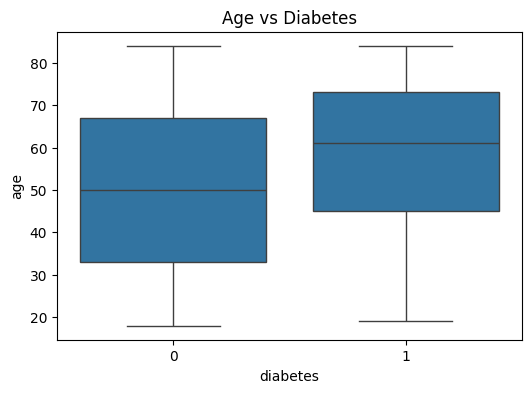

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x='diabetes', y='age', data=data)
plt.title("Age vs Diabetes")
plt.show()

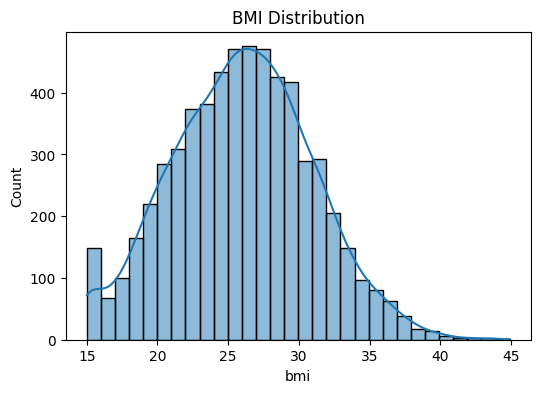

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(data['bmi'], bins=30, kde=True)
plt.title("BMI Distribution")
plt.show()

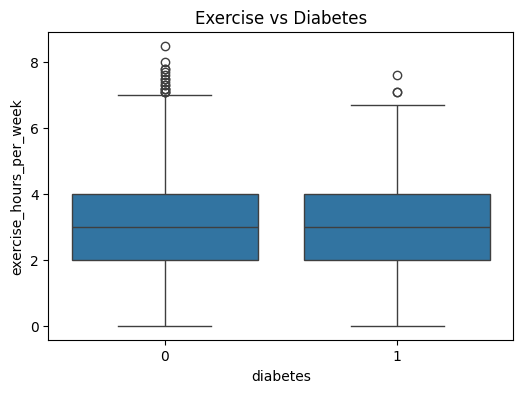

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x='diabetes', y='exercise_hours_per_week', data=data)
plt.title("Exercise vs Diabetes")
plt.show()

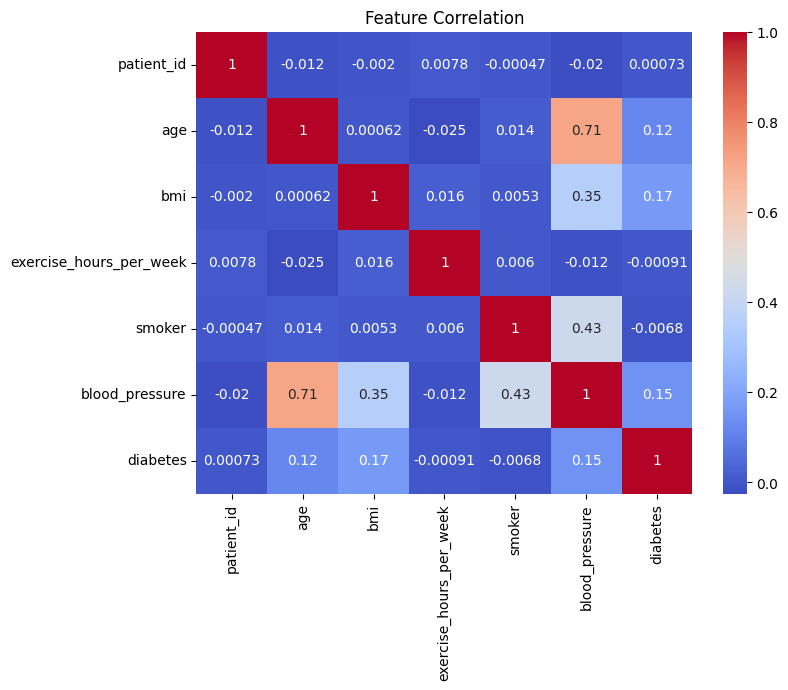

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [26]:
X = data.drop(['patient_id', 'diabetes'], axis=1)
y = data['diabetes']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [32]:
y_pred = log_model.predict(X_test_scaled)
print("Predictions:", y_pred[:10])

Predictions: [0 0 0 0 0 0 0 0 0 0]


In [33]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.91
Confusion Matrix:
 [[1092    0]
 [ 108    0]]
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [34]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [35]:
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],), name='input_layer'),
    layers.Dense(32, activation='relu', name='hidden_layer_1'),
    layers.Dense(16, activation='relu', name='hidden_layer_2'),
    layers.Dense(1, activation='sigmoid', name='output_layer')
])


In [36]:
nn_model.compile(
    optimizer='adam',
    loss=keras.losses.BinaryCrossentropy(name='binary_crossentropy'),
    metrics=['accuracy']
)

In [37]:
history = nn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=10
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9038 - loss: 0.3814 - val_accuracy: 0.9100 - val_loss: 0.2930
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9096 - loss: 0.2890 - val_accuracy: 0.9100 - val_loss: 0.2849
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9096 - loss: 0.2842 - val_accuracy: 0.9100 - val_loss: 0.2845
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9096 - loss: 0.2825 - val_accuracy: 0.9100 - val_loss: 0.2872
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9096 - loss: 0.2816 - val_accuracy: 0.9100 - val_loss: 0.2828
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9096 - loss: 0.2801 - val_accuracy: 0.9100 - val_loss: 0.2840
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9096 - loss: 0.2800 - val_accuracy: 0.9100 - val_loss: 0.2836
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9096 - loss: 0.2797 - val_accuracy: 0.

In [38]:
test_loss, test_accuracy = nn_model.evaluate(X_test_scaled, y_test)
print("Test Accuracy:", test_accuracy)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9100 - loss: 0.2822
Test Accuracy: 0.9100000262260437


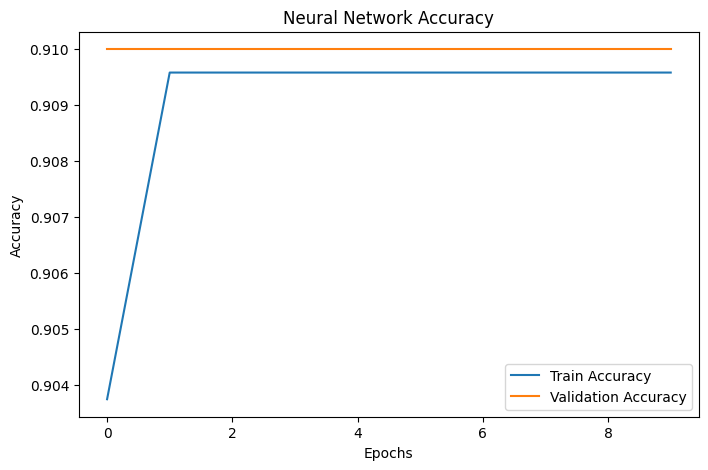

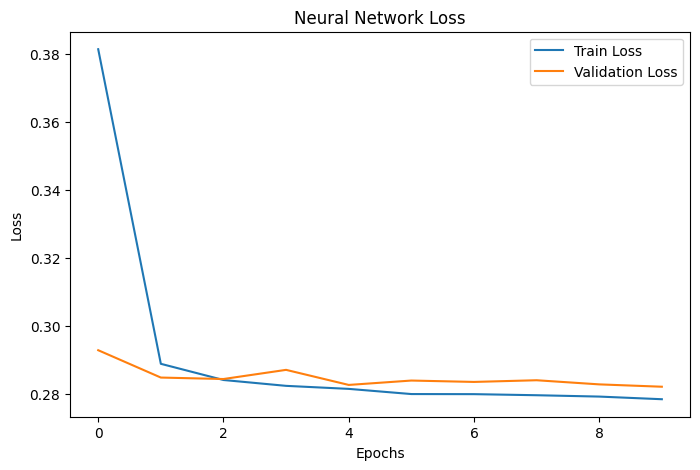

In [39]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Neural Network Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [42]:
y_pred_lr = log_model.predict(X_test_scaled)
y_pred_nn = nn_model.predict(X_test_scaled)
y_pred_nn = (y_pred_nn > 0.5).astype(int)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [43]:
print("=== Logistic Regression Metrics ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\n=== Neural Network Metrics ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("Precision:", precision_score(y_test, y_pred_nn))
print("Recall:", recall_score(y_test, y_pred_nn))
print("F1 Score:", f1_score(y_test, y_pred_nn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))

=== Logistic Regression Metrics ===
Accuracy: 0.91
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Confusion Matrix:
 [[1092    0]
 [ 108    0]]

=== Neural Network Metrics ===
Accuracy: 0.91
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Confusion Matrix:
 [[1092    0]
 [ 108    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
